### GOAL 
Notebook aims to disentangle HGSOC RNA data into 2+ data spaces (Cell Cycle Signal Space, Inteferon Signal Space, Cell Dissociation Signal Space, Cell Type Signal Space)

In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding, visualize_2d

In [4]:
adata = sc.read_h5ad("../../../data/brca/adata_inferploidy_example.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 33742 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'sample_ext', 'celltype_major', 'celltype_minor', 'celltype_subset', 'cnv_ref_ind', 'ploidy_score', 'ploidy_dec', 'ploidy_init_group', 'condition_for_deg', 'sample_ext_for_deg', 'celltype_for_deg', 'celltype_for_cci', 'tumor_origin_ind', 'iploidy_score', 'iploidy_dec', 'iploidy_init_group'
    var: 'variable_genes', 'chr', 'spot_no', 'cytogenetic_band', 'chromosome', 'start', 'end', 'gene_id', 'gene_name'
    uns: 'CCI', 'CCI_sample', 'Celltype_marker_DB', 'DEG', 'DEG_grouping_vars', 'DEG_stat', 'DEG_vs_ref', 'DEG_vs_ref_stat', 'GSA_down', 'GSA_up', 'GSA_vs_ref_down', 'GSA_vs_ref_up', 'GSEA', 'GSEA_vs_ref', 'HiCAT_summary', 'Pathways_DB', 'analysis_parameters', 'celltype_major_colors', 'cnv', 'cnv_neighbors', 'cnv_neighbors_info', 'condition_colors', 'gene_to_band_map', 'infe

In [6]:
adata.obs.columns.unique()

Index(['Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity',
       'Gender', 'geo_no', 'subtype', 'subtype_detail', 'tissue', 'condition',
       'sample', 'sample_ext', 'celltype_major', 'celltype_minor',
       'celltype_subset', 'cnv_ref_ind', 'ploidy_score', 'ploidy_dec',
       'ploidy_init_group', 'condition_for_deg', 'sample_ext_for_deg',
       'celltype_for_deg', 'celltype_for_cci', 'tumor_origin_ind',
       'iploidy_score', 'iploidy_dec', 'iploidy_init_group'],
      dtype='object')

In [17]:
adata.obs["celltype_major"].unique()

['Epithelial cell', 'Myeloid cell', 'T cell', 'Smooth muscle cell', 'Fibroblast', 'Endothelial cell', 'B cell', 'Mast cell']
Categories (8, object): ['B cell', 'Endothelial cell', 'Epithelial cell', 'Fibroblast', 'Mast cell', 'Myeloid cell', 'Smooth muscle cell', 'T cell']

In [10]:
adata.obs["celltype_minor"].unique()

['Macrophage', 'Epithelial cell', 'Mast cell', 'Fibroblast', 'B cell', ..., 'T cell CD8+', 'Plasma cell', 'ILC', 'NK cell', 'unassigned']
Length: 14
Categories (14, object): ['B cell', 'Dendritic cell', 'Endothelial cell', 'Epithelial cell', ..., 'Smooth muscle cell', 'T cell CD4+', 'T cell CD8+', 'unassigned']

In [11]:
np.unique(adata.obs["condition"].tolist(), return_counts = True)

(array(['ER+', 'HER2+', 'Normal', 'TNBC'], dtype='<U6'),
 array([8994, 7500, 8965, 8283]))

In [12]:
# Replication Stress V1: Try to Capture Replication Stress For HER2+ Type Cancers Only 

In [13]:
adata = adata[adata.obs["condition"] == "HER2+"]

In [14]:
adata

View of AnnData object with n_obs × n_vars = 7500 × 22585
    obs: 'Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity', 'Gender', 'geo_no', 'subtype', 'subtype_detail', 'tissue', 'condition', 'sample', 'sample_ext', 'celltype_major', 'celltype_minor', 'celltype_subset', 'cnv_ref_ind', 'ploidy_score', 'ploidy_dec', 'ploidy_init_group', 'condition_for_deg', 'sample_ext_for_deg', 'celltype_for_deg', 'celltype_for_cci', 'tumor_origin_ind', 'iploidy_score', 'iploidy_dec', 'iploidy_init_group'
    var: 'variable_genes', 'chr', 'spot_no', 'cytogenetic_band', 'chromosome', 'start', 'end', 'gene_id', 'gene_name'
    uns: 'CCI', 'CCI_sample', 'Celltype_marker_DB', 'DEG', 'DEG_grouping_vars', 'DEG_stat', 'DEG_vs_ref', 'DEG_vs_ref_stat', 'GSA_down', 'GSA_up', 'GSA_vs_ref_down', 'GSA_vs_ref_up', 'GSEA', 'GSEA_vs_ref', 'HiCAT_summary', 'Pathways_DB', 'analysis_parameters', 'celltype_major_colors', 'cnv', 'cnv_neighbors', 'cnv_neighbors_info', 'condition_colors', 'gene_to_band_map'

### Sanity-Checking the Data

In [18]:
np.min(adata.X.todense())

0.0

In [19]:
np.max(adata.X.todense()) 

6846.0

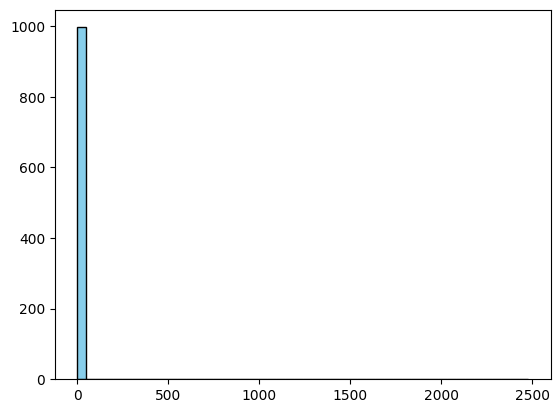

In [20]:
sample = np.random.choice(np.asarray(adata.X.todense()).flatten(), size=1000, replace=False)

# Plot histogram
plt.hist(sample, bins=50, color='skyblue', edgecolor='black')
plt.show()

### Pre-processing

In [21]:
adata.var["gene_symbols"] = adata.var["gene_name"]

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_69592/1799674669.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["gene_symbols"] = adata.var["gene_name"]


In [22]:
replication_stress_genes_path = "../../../genes/HGSOC/replication_stress/human_replication_stress_genes_jungk.tsv"  
replication_stress_genes = pd.read_csv(replication_stress_genes_path, header = None, sep="\t")

In [23]:
## Brief Analysis of Number of Relevant Genes Found 

In [24]:
replication_stress_genes_set = set(replication_stress_genes.iloc[:,0]) 

In [25]:
contained_genes_replication_stress = adata.var["gene_symbols"].isin(replication_stress_genes[0])

In [26]:
print(f"Number of replication stress genes present in adata: {np.sum(contained_genes_replication_stress)} out of {len(replication_stress_genes_set)}")

Number of replication stress genes present in adata: 17 out of 21


In [27]:
# Order Genes in adata such that genes appear in following order: cell cycle genes, interferon genes, dissociation genes
replication_stress_indices = np.where(contained_genes_replication_stress)[0]

all_known_indices = np.hstack((replication_stress_indices))
remaining_indices = np.setdiff1d(np.arange(adata.shape[1]), all_known_indices)

rearranged_indices = np.hstack((replication_stress_indices, remaining_indices))
rearranged_indices = rearranged_indices.astype(int)

In [28]:
adata = adata[:, rearranged_indices] # .copy() is safer in AnnData
adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_69592/1082852305.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!


### Pre-processing x2 - Calculating Gene-Enrichment Scores 

In [29]:
from anndata.utils import make_index_unique

# 1. Get the gene symbols and convert to a standard pandas Index
temp_index = pd.Index(adata.var['gene_symbols'].astype(str))

# 2. Use the anndata utility to make the index unique (appends -1, -2, etc. to duplicates)
adata.var_names = make_index_unique(temp_index)
adata.var_names.name = None
adata.raw = adata ### TODO - maybe we can remove this 

In [30]:
sc.tl.score_genes(
    adata,
    gene_list=replication_stress_genes_set,
    score_name="replication_stress_score"
)

Text(0.5, 1.0, 'Tumour Replication Stress Score (TRSS) Distribution')

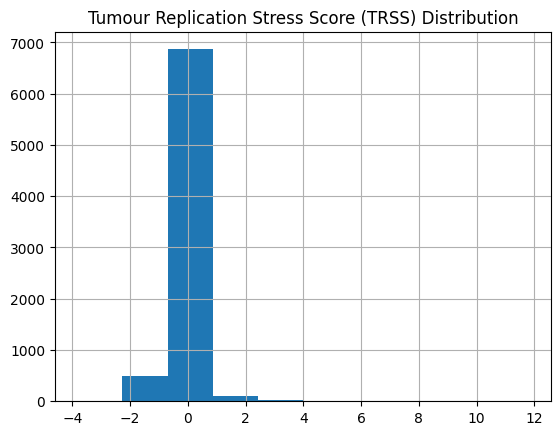

In [23]:
ax = adata.obs["replication_stress_score"].hist()
ax.set_title("Tumour Replication Stress Score (TRSS) Distribution")

In [24]:
adata.obs["Source"].unique()

['Total']
Categories (1, object): ['Total']

In [25]:
adata.obs["Condition"].unique()

['HER2+ tumor']
Categories (1, object): ['HER2+ tumor']

In [26]:
adata.obs["sample"].unique()

['HER2-AH0308', 'HER2-MH0031', 'HER2-MH0161', 'HER2-MH0176', 'HER2-PM0337']
Categories (5, object): ['HER2-AH0308', 'HER2-MH0031', 'HER2-MH0161', 'HER2-MH0176', 'HER2-PM0337']

In [27]:
adata.obs["sample_ext"].unique()

['HER2+ HER2-AH0308', 'HER2+ HER2-MH0031', 'HER2+ HER2-MH0161', 'HER2+ HER2-MH0176', 'HER2+ HER2-PM0337']
Categories (5, object): ['HER2+ HER2-AH0308', 'HER2+ HER2-MH0031', 'HER2+ HER2-MH0161', 'HER2+ HER2-MH0176', 'HER2+ HER2-PM0337']

In [28]:
adata.obs.columns.unique()

Index(['Patient', 'Description', 'Source', 'Condition', 'Menopause', 'Parity',
       'Gender', 'geo_no', 'subtype', 'subtype_detail', 'tissue', 'condition',
       'sample', 'sample_ext', 'celltype_major', 'celltype_minor',
       'celltype_subset', 'cnv_ref_ind', 'ploidy_score', 'ploidy_dec',
       'ploidy_init_group', 'condition_for_deg', 'sample_ext_for_deg',
       'celltype_for_deg', 'celltype_for_cci', 'tumor_origin_ind',
       'iploidy_score', 'iploidy_dec', 'iploidy_init_group',
       'replication_stress_score'],
      dtype='object')

### Model Configuration

In [31]:
model_name = "e2, e10"

In [32]:
from src.celluntangler.models.get_config import get_config
config = get_config()
config.model_name = model_name
config.seed = 68715
config.init = "custom"
config.max_epochs = 500 
config.epochs = 500

In [33]:
if config.seed:  
    torch.manual_seed(config.seed)
    np.random.seed(config.seed) 
    np.random.default_rng(config.seed)
components = utils.parse_components(model_name, config.fixed_curvature) 

### Creating Training Dataset

In [34]:
# TODO - handle batch effects for BRCA dataset 
if not "batch" in adata.obs.columns.tolist(): 
    adata.obs["batch"] = adata.obs.index.str.split("_").str[0]
    adata.obs["batch"] = adata.obs["sample"].astype("category")

In [35]:
adata.obs["batch"].unique()

['HER2-AH0308', 'HER2-MH0031', 'HER2-MH0161', 'HER2-MH0176', 'HER2-PM0337']
Categories (5, object): ['HER2-AH0308', 'HER2-MH0031', 'HER2-MH0161', 'HER2-MH0176', 'HER2-PM0337']

In [36]:
batch = adata.obs.batch.cat.codes.values 
batch = batch[:,None]
batch = batch.astype(np.int64) 

In [37]:
# One entry in n_batch for each "factor of batch effects"
config.n_batch = [ len(np.unique(batch)) ]

In [38]:
batch_counts = np.bincount(batch[:,0])
batch_counts = batch_counts[1:]

In [39]:
# Creating Training Dataset
x = adata.X.todense().astype(np.double)

In [40]:
# y holds the batch vector for the dataset
y = batch 
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

in_dim = 22585
dataset.in_dim = 22585
Dataset seed: 68715


In [41]:
# Creating (Disjoint) Masks
mask_replication_stress = np.zeros(adata.n_vars)
mask_replication_stress[adata.var["gene_symbols"].isin(replication_stress_genes[0])] = 1

mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(replication_stress_genes[0])] = 0 

mask = torch.tensor([mask_replication_stress, mask_all])

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_69592/1043066249.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  mask = torch.tensor([mask_replication_stress, mask_all])


### Configure Save Paths

In [42]:
epoch_embeddings_save_path = "../../../results/replication_stress"
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

In [41]:
# TODO - add functionality for plotting a log-likelihood plot every 50 epochs or so

In [42]:
"""
import umap
M = np.asarray(x)  # ensure ndarray (important if it's a numpy.matrix)

n_samples = 400
idx = np.random.choice(M.shape[0], size=n_samples, replace=False)
M_sub = M[idx]
M_sub.shape == (400, 31815)

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

embedding = reducer.fit_transform(M_sub)

plt.figure(figsize=(6, 6))
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=15,
    alpha=0.7
)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP of 400 Randomly Sampled Rows")
plt.show()
"""

'\nimport umap\nM = np.asarray(x)  # ensure ndarray (important if it\'s a numpy.matrix)\n\nn_samples = 400\nidx = np.random.choice(M.shape[0], size=n_samples, replace=False)\nM_sub = M[idx]\nM_sub.shape == (400, 31815)\n\nreducer = umap.UMAP(\n    n_neighbors=15,\n    min_dist=0.1,\n    n_components=2,\n    random_state=42\n)\n\nembedding = reducer.fit_transform(M_sub)\n\nplt.figure(figsize=(6, 6))\nplt.scatter(\n    embedding[:, 0],\n    embedding[:, 1],\n    s=15,\n    alpha=0.7\n)\nplt.xlabel("UMAP-1")\nplt.ylabel("UMAP-2")\nplt.title("UMAP of 400 Randomly Sampled Rows")\nplt.show()\n'

### Model Creation

In [43]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [44]:
torch.set_default_dtype(torch.float64)

In [45]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
EuclideanComponent(R^2)


### Training

In [46]:
trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)

trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                       visualize_information=visualize_information)

KeyboardInterrupt: 

### Saving Embeddings

In [46]:
embeddings_save_path = epoch_embeddings_save_path

In [47]:
a = trainer.model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'), a[4].detach().to(torch.device("cpu")).numpy())

NameError: name 'trainer' is not defined

### Analysis

In [48]:
gene_expression_matrix_path = epoch_embeddings_save_path

In [49]:
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params.txt'))
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

e2 2
e10 10


#### Visualization of UMAP of Original scRNA Matrix

Copy Number Variation UMAP

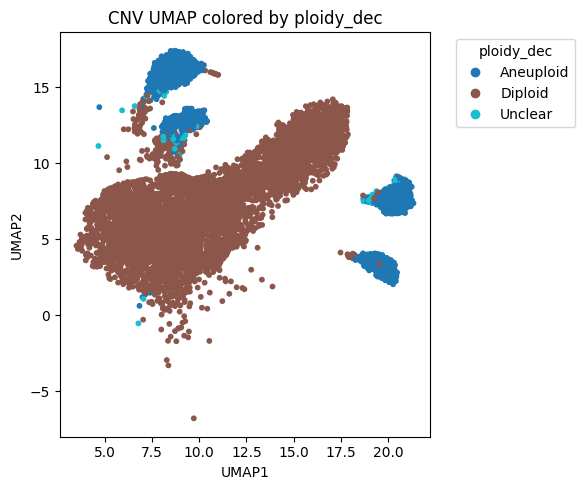

In [61]:
# Extract UMAP coordinates
umap = adata.obsm["X_cnv_umap"]
x = umap[:, 0]
y = umap[:, 1]

# Categorical annotation
cats = pd.Categorical(adata.obs["ploidy_dec"])
codes = cats.codes          # integers for coloring
labels = cats.categories    # category names

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    x, y,
    c=codes,
    s=10,
    cmap="tab10"   # or tab20 if many categories
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("CNV UMAP colored by ploidy_dec")

# Proper categorical legend
handles = sc.legend_elements()[0]
plt.legend(
    handles,
    labels,
    title="ploidy_dec",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Original RNA Expression UMAP

In [65]:
adata.obsm["X_pca"].shape

(7500, 15)

In [ ]:
# Use existing PCA
sc.pp.neighbors(
    adata,
    use_rep="X_pca",   # <- key point
    n_neighbors=15,
    n_pcs=15           # adjust if needed
)

sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color="cell_type"  # or ploidy_dec, tumor_score, etc.
)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


#### Visualization of Component 1 (E2)

##### Visualization fo Replication Stress Signals

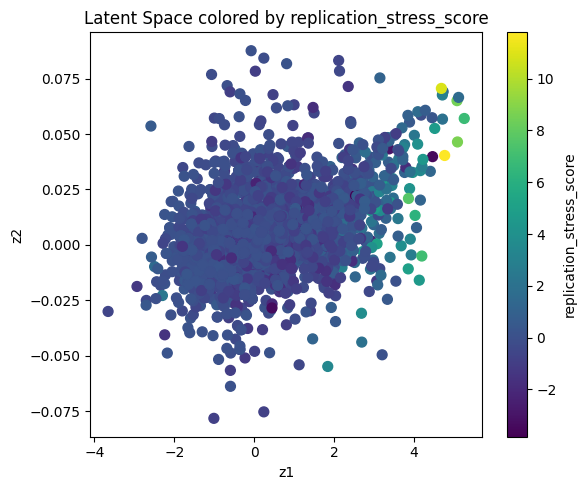

In [52]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component1_e2"
desired_obs = 'replication_stress_score'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation=desired_obs
)

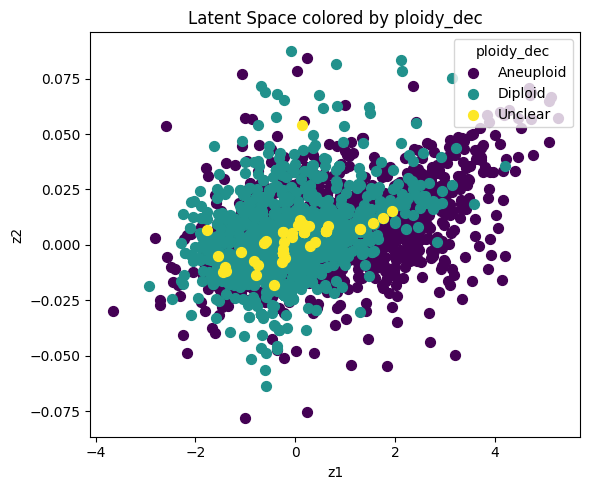

In [53]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component1_e2"
desired_obs = 'ploidy_dec'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation=desired_obs
)

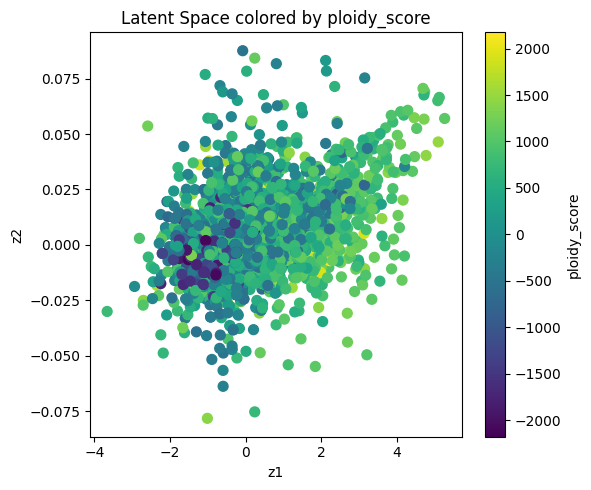

In [50]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component1_e2"
desired_obs = 'ploidy_score'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation=desired_obs
)

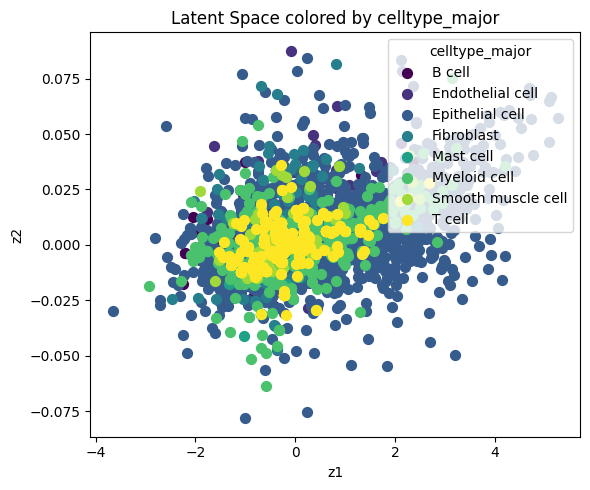

In [51]:
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component1_e2"
desired_obs = 'celltype_major'

visualize_2d(
    embeddings=adata.obsm[embeddings_key],
    adata = adata, 
    annotation=desired_obs
)

#### Visualization of Component 2 (E10)

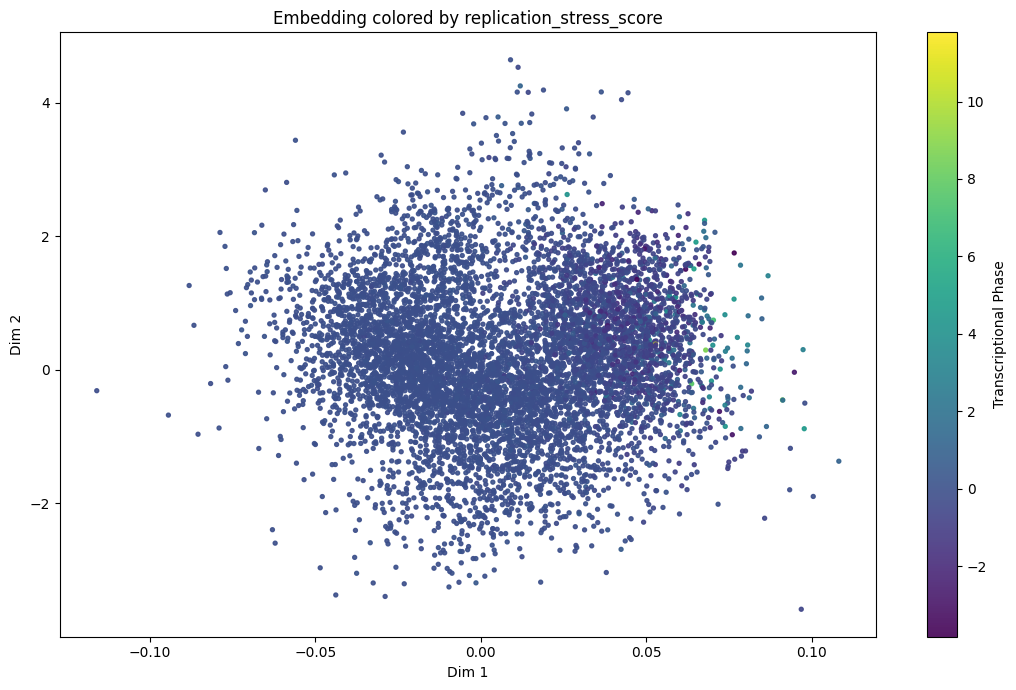

In [55]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'replication_stress_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase"
)

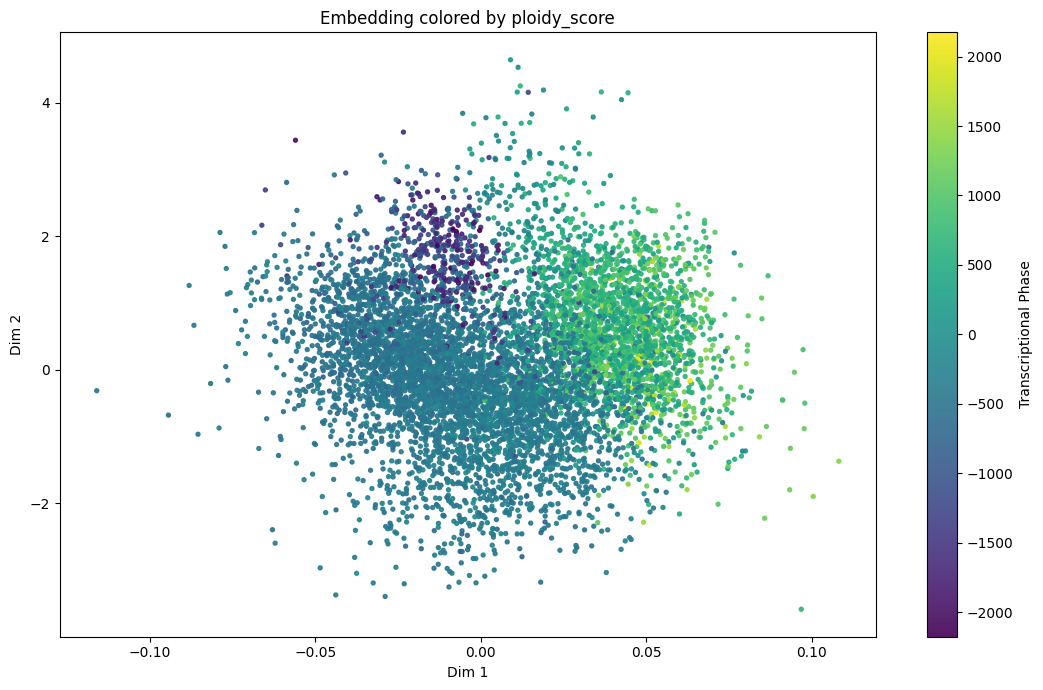

In [56]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'ploidy_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase"
)

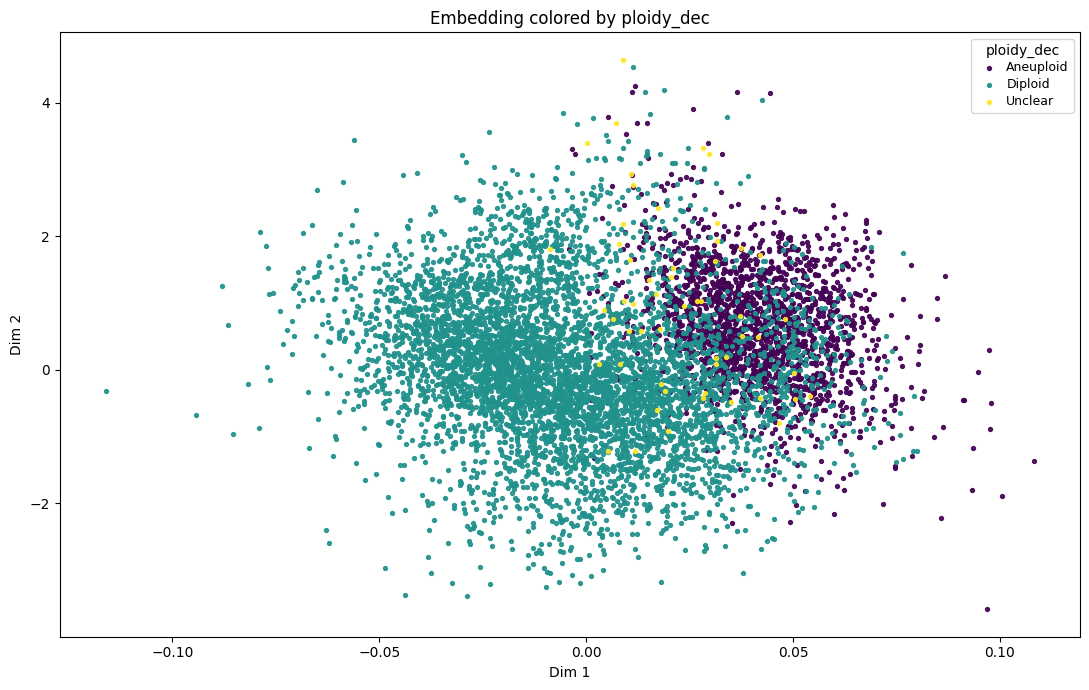

In [57]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'ploidy_dec'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label="Transcriptional Phase"
)

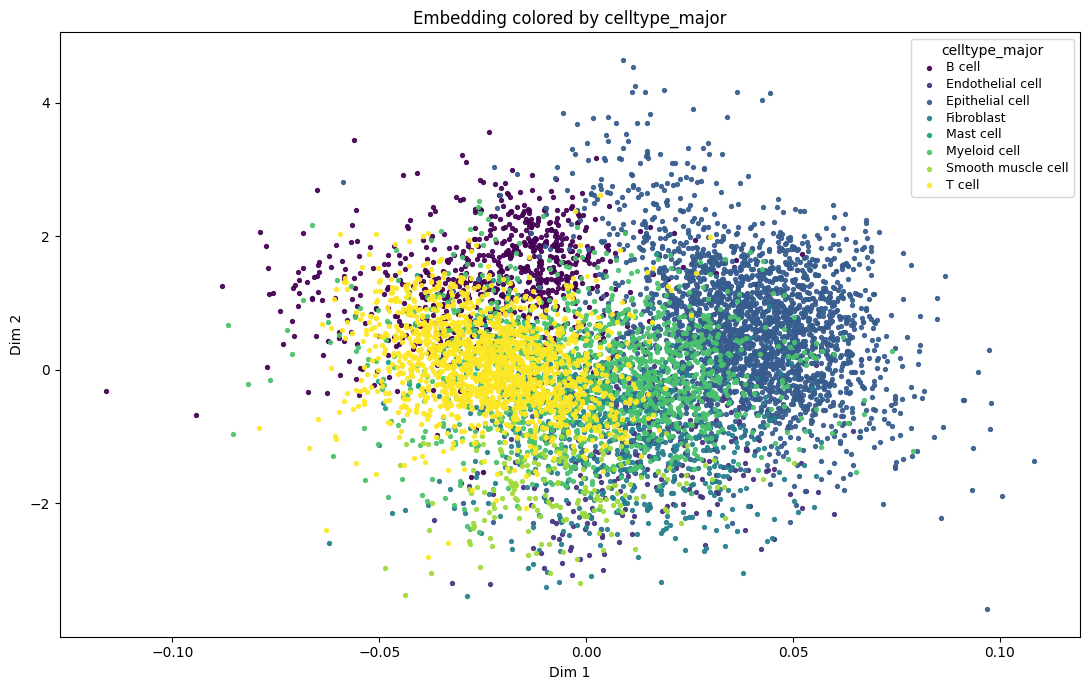

In [52]:
# TODO - add custom UMAP code that doesn't hang! 
# For preliminary analysis - just measure enrichment in some marker gene of cell dissociation response
# For preliminary analysis - just measure enrichment in some marker gene of interferon response
embeddings_key = "component2_e10"
desired_obs = 'celltype_major'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs
)

#### Pairwise Plots - 1 Sanity Check Against Sarah's Work

In [54]:
for cell_type in adata.obs["cell_type"].unique(): 
    print(cell_type)

T cell
fallopian tube secretory epithelial cell
fibroblast
monocyte
plasma cell
dendritic cell
endothelial cell
B cell
mast cell


In [55]:
mask_tcell = adata.obs["cell_type"] == "T cell"
mask_fallopian = adata.obs["cell_type"] == "fallopian tube secretory epithelial cell"
mask_fibroblast = adata.obs["cell_type"] == "fibroblast"
mask_monocyte = adata.obs["cell_type"] == "monocyte"
mask_plasma = adata.obs["cell_type"] == "plasma cell"
mask_dendritic = adata.obs["cell_type"] == "dendritic cell"
mask_endothelial = adata.obs["cell_type"] == "endothelial cell"
mask_bcell = adata.obs["cell_type"] == "B cell"
mask_mast = adata.obs["cell_type"] == "mast cell"

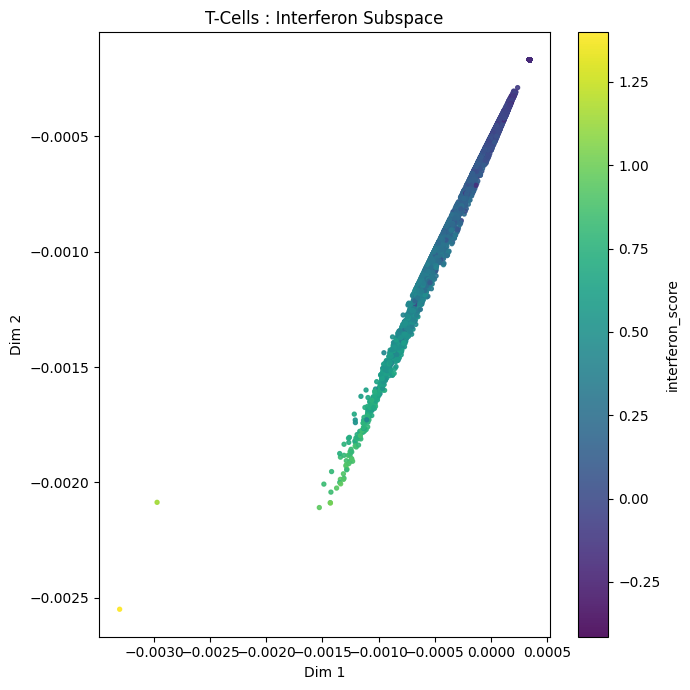

In [56]:
# T-cells
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_tcell],
    obs_values=adata.obs[desired_obs][mask_tcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "T-Cells : Interferon Subspace" 
)

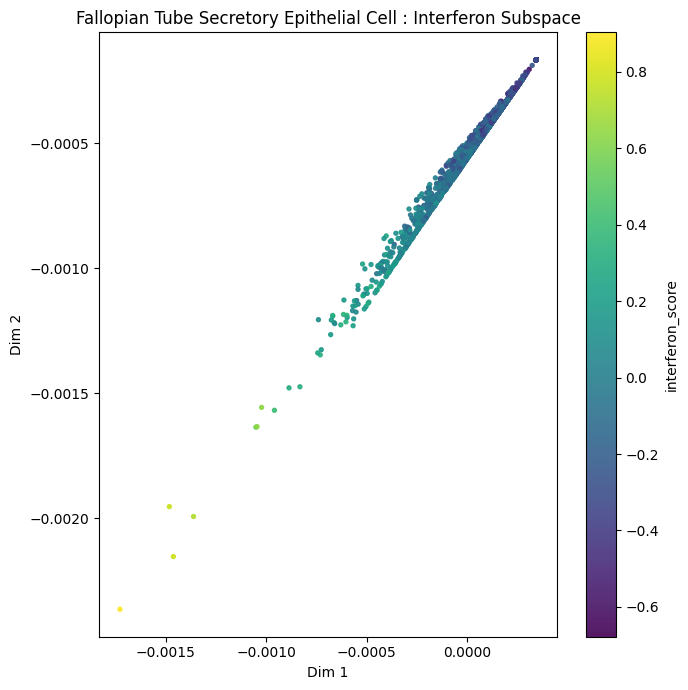

In [57]:
# Fallopian tube secretory epithelial cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fallopian],
    obs_values=adata.obs[desired_obs][mask_fallopian],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fallopian Tube Secretory Epithelial Cell : Interferon Subspace" 
)

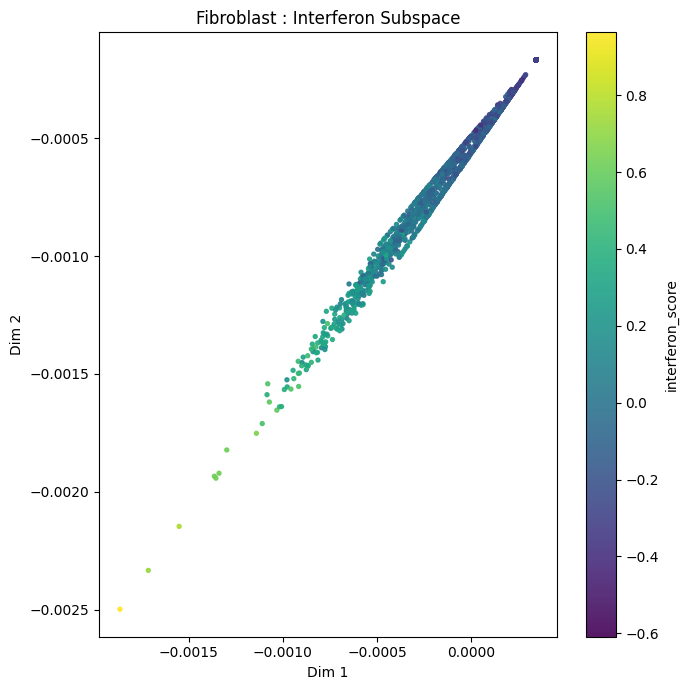

In [58]:
# Fibroblast 
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fibroblast],
    obs_values=adata.obs[desired_obs][mask_fibroblast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fibroblast : Interferon Subspace" 
)

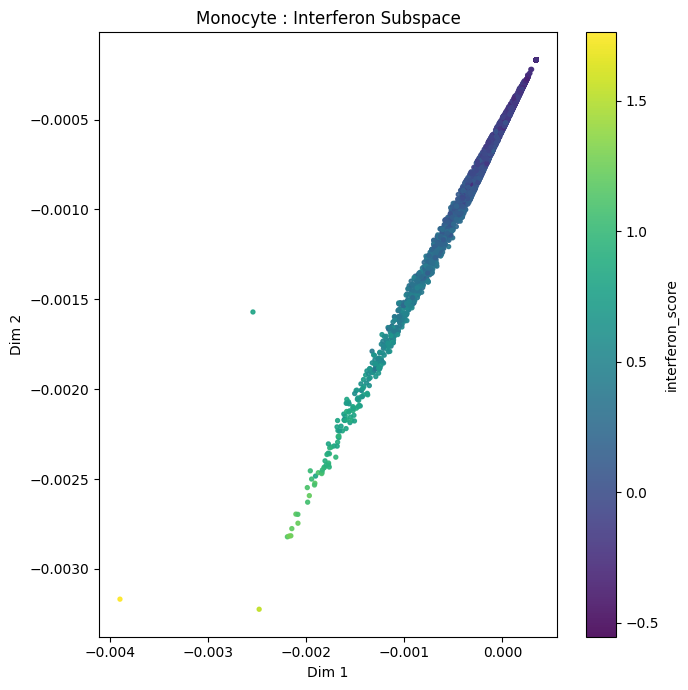

In [59]:
# Monocyte
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_monocyte],
    obs_values=adata.obs[desired_obs][mask_monocyte],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Monocyte : Interferon Subspace" 
)

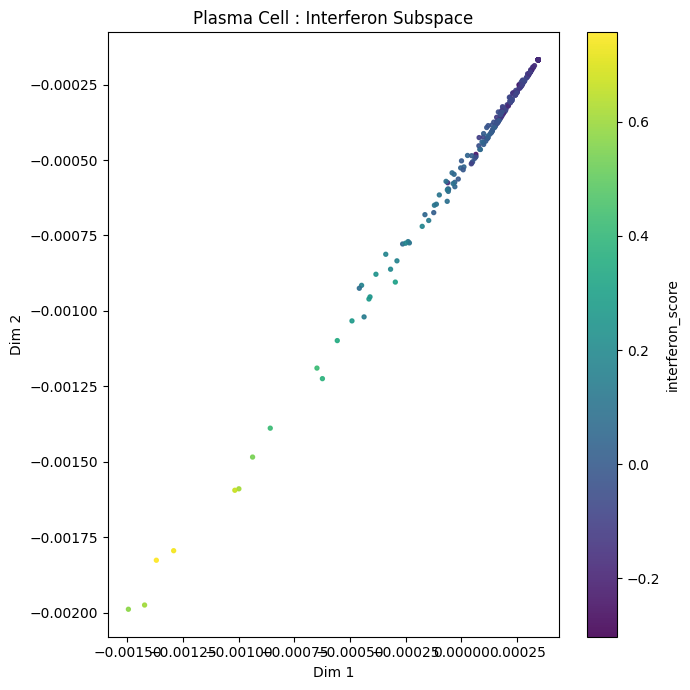

In [60]:
# Plasma cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_plasma],
    obs_values=adata.obs[desired_obs][mask_plasma],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Plasma Cell : Interferon Subspace" 
)

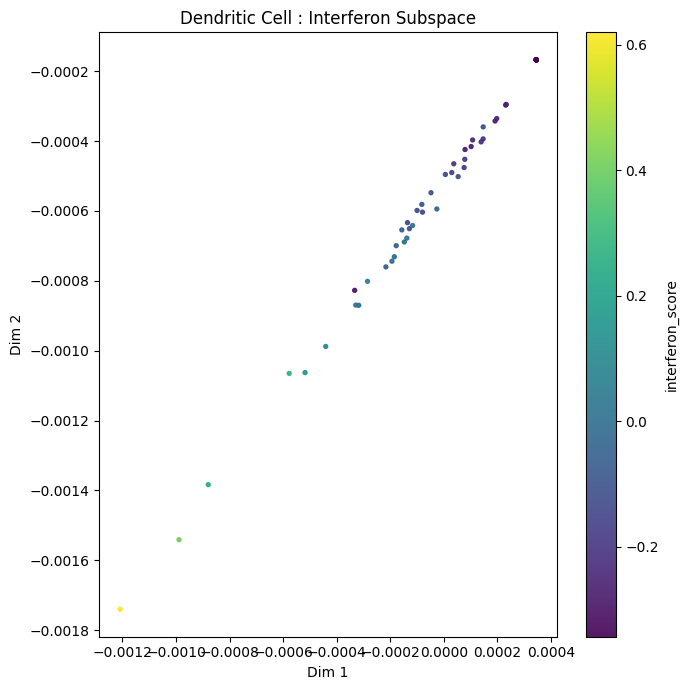

In [61]:
# Dendritic cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_dendritic],
    obs_values=adata.obs[desired_obs][mask_dendritic],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Dendritic Cell : Interferon Subspace" 
)

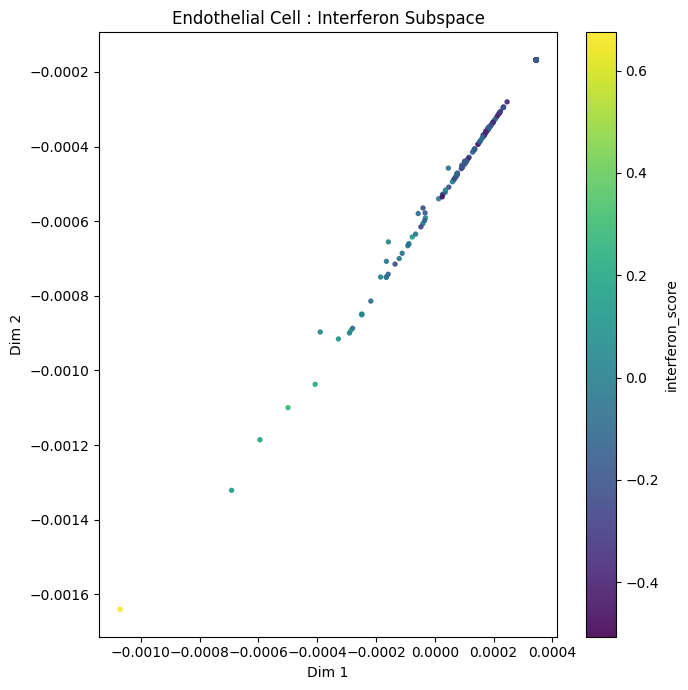

In [62]:
# Endothelial cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_endothelial],
    obs_values=adata.obs[desired_obs][mask_endothelial],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Endothelial Cell : Interferon Subspace" 
)

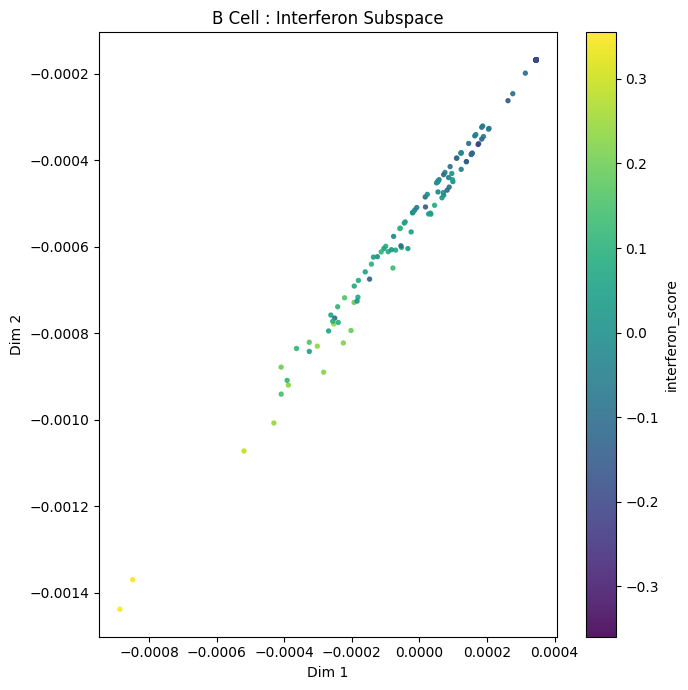

In [63]:
# B cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_bcell],
    obs_values=adata.obs[desired_obs][mask_bcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "B Cell : Interferon Subspace" 
)

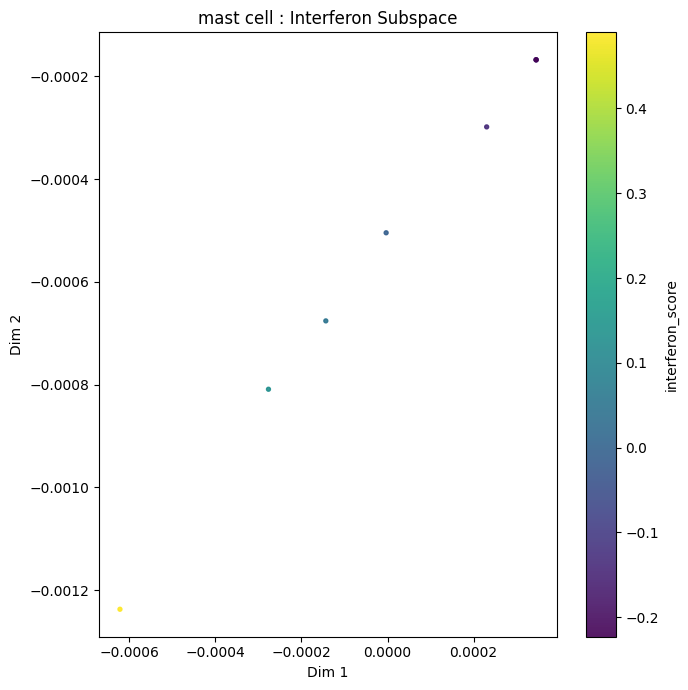

In [64]:
# mast cell
embeddings_key = "component2_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_mast],
    obs_values=adata.obs[desired_obs][mask_mast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "mast cell : Interferon Subspace" 
)

#### Pairwise Plots - 2 Dissociation Experiments

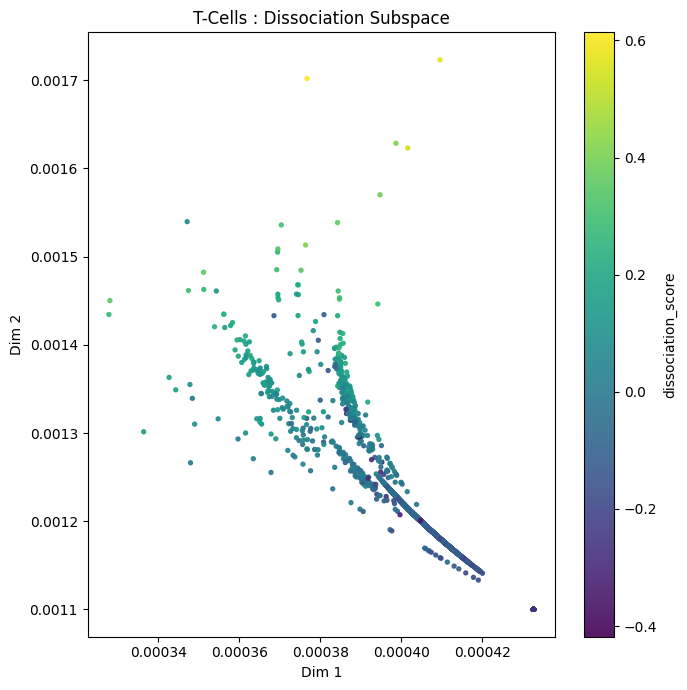

In [65]:
# T-cells
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_tcell],
    obs_values=adata.obs[desired_obs][mask_tcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "T-Cells : Dissociation Subspace" 
)

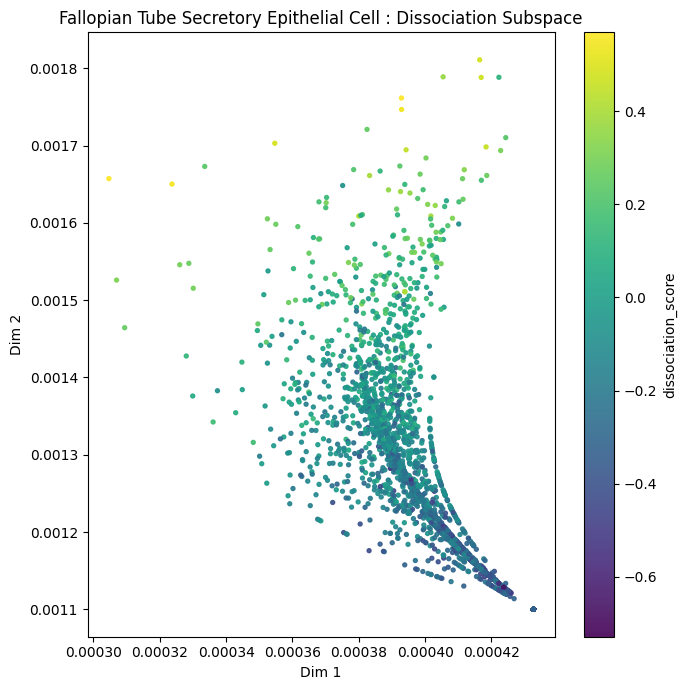

In [66]:
# Fallopian tube secretory epithelial cell
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fallopian],
    obs_values=adata.obs[desired_obs][mask_fallopian],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fallopian Tube Secretory Epithelial Cell : Dissociation Subspace" 
)

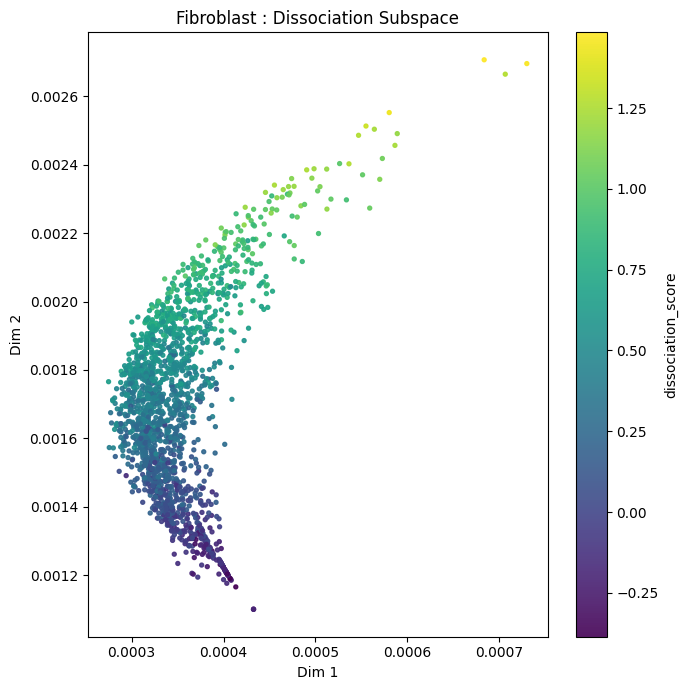

In [67]:
# Fibroblast 
embeddings_key = "component3_e10"
desired_obs = 'dissociation_score'
visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_fibroblast],
    obs_values=adata.obs[desired_obs][mask_fibroblast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Fibroblast : Dissociation Subspace" 
)

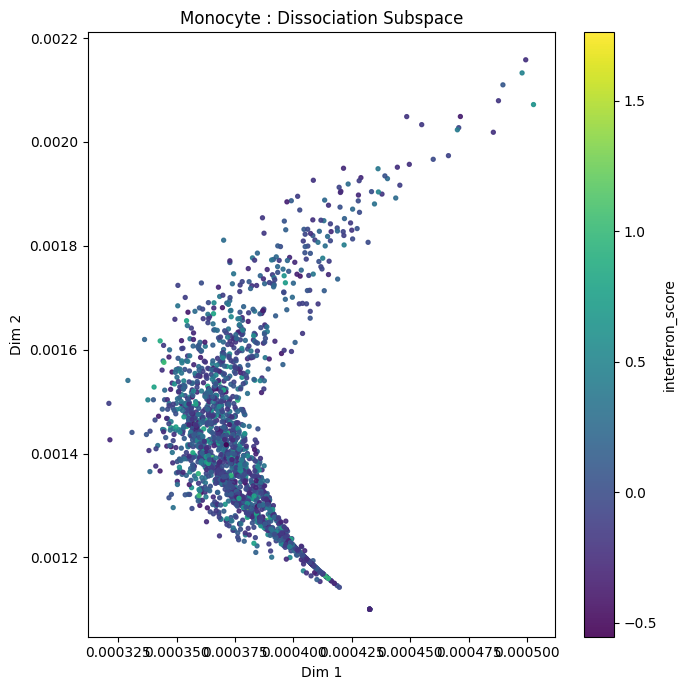

In [68]:
# Monocyte
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_monocyte],
    obs_values=adata.obs[desired_obs][mask_monocyte],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Monocyte : Dissociation Subspace" 
)

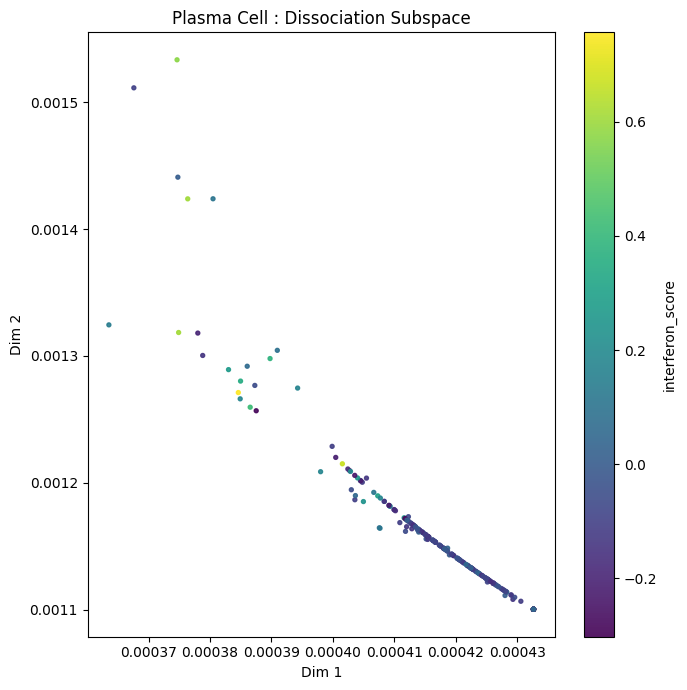

In [69]:
# Plasma cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_plasma],
    obs_values=adata.obs[desired_obs][mask_plasma],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Plasma Cell : Dissociation Subspace" 
)

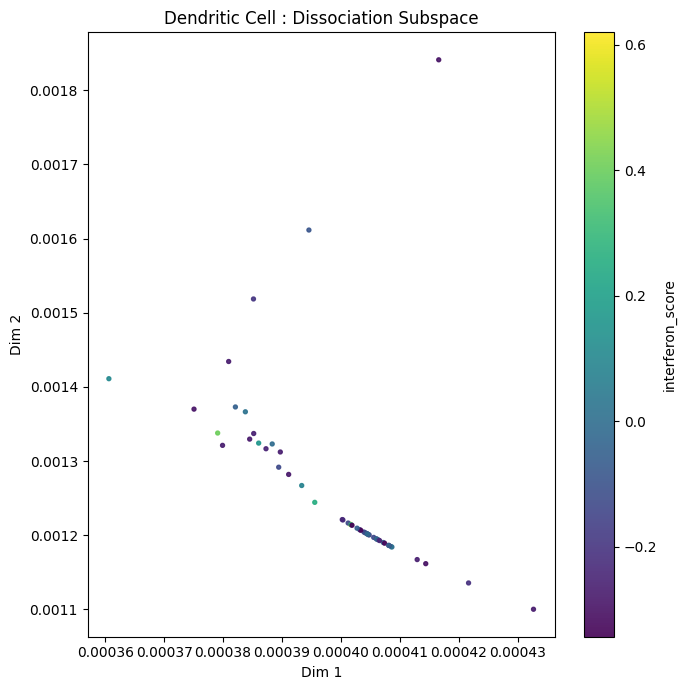

In [70]:
# Dendritic cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_dendritic],
    obs_values=adata.obs[desired_obs][mask_dendritic],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Dendritic Cell : Dissociation Subspace" 
)

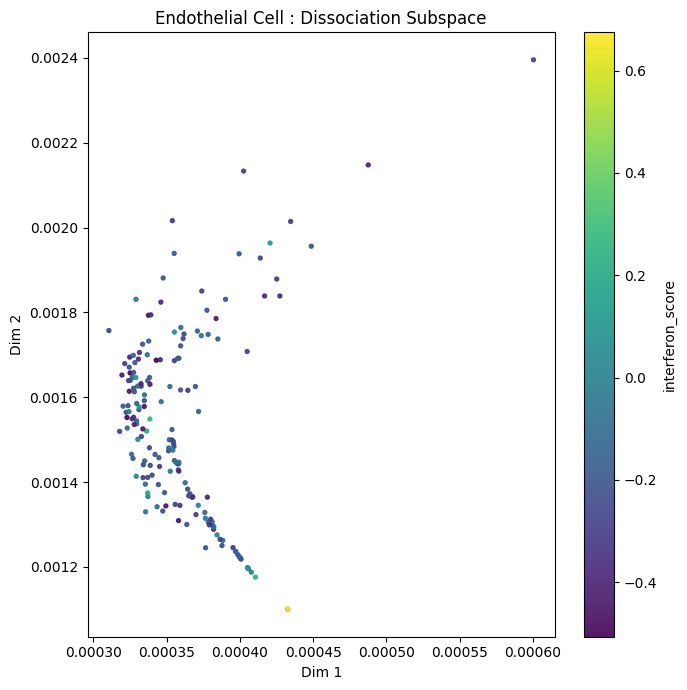

In [71]:
# Endothelial cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_endothelial],
    obs_values=adata.obs[desired_obs][mask_endothelial],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "Endothelial Cell : Dissociation Subspace" 
)

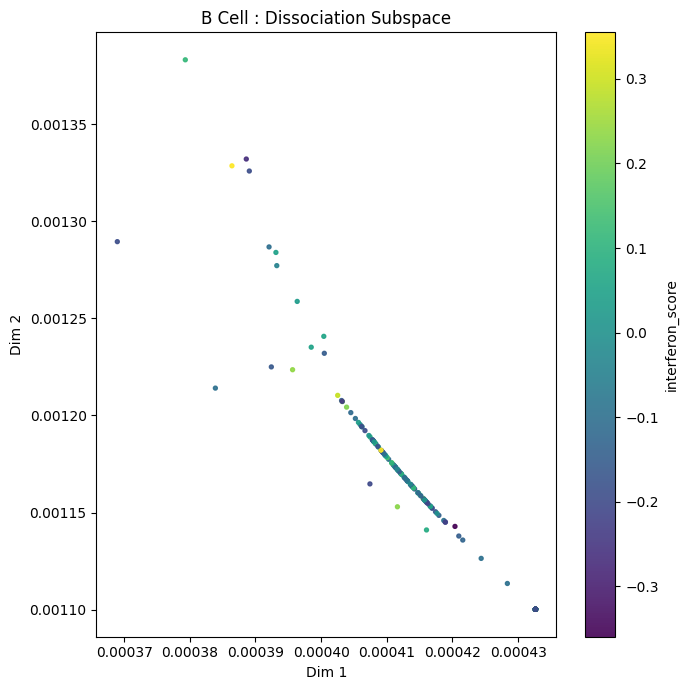

In [72]:
# B cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_bcell],
    obs_values=adata.obs[desired_obs][mask_bcell],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "B Cell : Dissociation Subspace" 
)

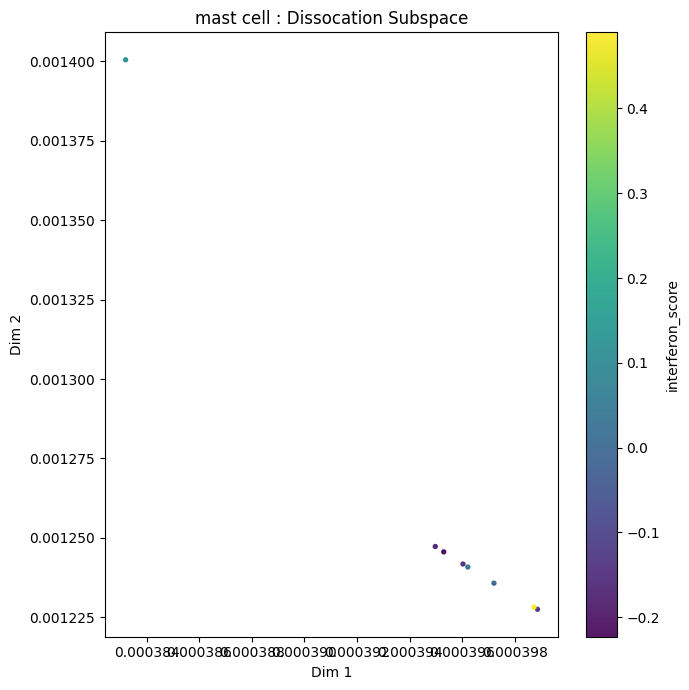

In [73]:
# mast cell
embeddings_key = "component3_e10"
desired_obs = 'interferon_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key][mask_mast],
    obs_values=adata.obs[desired_obs][mask_mast],
    cmap=plt.cm.viridis,
    c_bar_label=desired_obs,
    bbox_to_anchor=(1.23, 1.01),
    title = "mast cell : Dissocation Subspace" 
)

In [67]:
adata.obs["cell_type"].unique()

cell_id
SPECTRUM-OV-070_S1_CD45P_ASCITES_CCGGTGAGTATGGAGC                                                   T cell
SPECTRUM-OV-037_S1_CD45N_LEFT_OVARY_GGGATCCTCATGCGGC              fallopian tube secretory epithelial cell
SPECTRUM-OV-054_S1_CD45P_INFRACOLIC_OMENTUM_TTGAACGTCCGCATAA                                        T cell
SPECTRUM-OV-041_S1_CD45N_RIGHT_FALLOPIAN_TUBE_TGTAAGCCACATACTG                                  fibroblast
SPECTRUM-OV-031_S1_CD45P_LEFT_FALLOPIAN_TUBE_CTCAAGAAGCACACAG                                       T cell
                                                                                    ...                   
SPECTRUM-OV-041_S1_CD45P_RIGHT_FALLOPIAN_TUBE_CTTGATTAGGCAGTCA                                      T cell
SPECTRUM-OV-054_S1_CD45N_INFRACOLIC_OMENTUM_CAGGGCTAGAGCCGAT                                    fibroblast
SPECTRUM-OV-082_S1_CD45N_BOWEL_GTCTTTAAGAAACTAC                   fallopian tube secretory epithelial cell
SPECTRUM-OV-009_S1_CD45P_RIGH

In [65]:
adata.obsm[embeddings_key]

array([[-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       ...,
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896],
       [-0.16527286,  0.23965319,  0.59899458, ...,  0.45320239,
        -0.52260051, -0.23355896]], shape=(10199, 10))

In [66]:
adata.obs[desired_obs]

cell_id
SPECTRUM-OV-070_S1_CD45P_ASCITES_CCGGTGAGTATGGAGC                -0.066753
SPECTRUM-OV-037_S1_CD45N_LEFT_OVARY_GGGATCCTCATGCGGC             -0.060493
SPECTRUM-OV-054_S1_CD45P_INFRACOLIC_OMENTUM_TTGAACGTCCGCATAA     -0.054439
SPECTRUM-OV-041_S1_CD45N_RIGHT_FALLOPIAN_TUBE_TGTAAGCCACATACTG   -0.080584
SPECTRUM-OV-031_S1_CD45P_LEFT_FALLOPIAN_TUBE_CTCAAGAAGCACACAG    -0.061362
                                                                    ...   
SPECTRUM-OV-041_S1_CD45P_RIGHT_FALLOPIAN_TUBE_CTTGATTAGGCAGTCA    0.003020
SPECTRUM-OV-054_S1_CD45N_INFRACOLIC_OMENTUM_CAGGGCTAGAGCCGAT     -0.224252
SPECTRUM-OV-082_S1_CD45N_BOWEL_GTCTTTAAGAAACTAC                  -0.173922
SPECTRUM-OV-009_S1_CD45P_RIGHT_OVARY_TCACTCGCATCTCGTC            -0.052288
SPECTRUM-OV-071_S1_CD45P_LEFT_OVARY_AGGCATTTCCGACAGC              0.029909
Name: G2M.Score, Length: 10199, dtype: float32

**QUESTIONS**
- Is using "everything else" to capture cell type really the best technique to use?
- Why does CellUntangler use the first latent subspace to reconstruct the genes that don't belong in the gene mask (when only the first latent subspace is used for reconstructing those genes that belong in the first gene mask)?
  A decision I need to might need to make (if the code doesn't already think about this and implement it)
  - Should all earlier subspaces contribute to the reconstruction of subsets of genes corresponding to later subspaces? Or, should only the last subset of genes (presumably corresponding to the largest number of genes) be reconstructed using the all latent subspaces up to the last subspace?
  - A sub-question: what guarantees disentanglement in models like CellUntangler?
  - Hmmm, if we stopped the gradient for all earlier subspaces when training later subspaces, would this ensure that earlier subspaces never "tweak" their parameters to get better at reconstructing a subset of genes unrelated to the subset of genes they should best reconstruct? 

What owu

**Worklist** 
- (HSSOC) Getting stuck on 2+ subspace CellUntangler (Get blocked on nuances of stopping gradients) 
- (Liver) Getting stuck on better benchmarking
- (Liver) Getting started on biological analysis of different dimensions + generating pairwise plots of disentangled dimensions 

**Ideas** 
- Might be useful to mix HGSOC dataset with non-cancerous cells to see how well the cell dissociation signal is captured in a particular latent space

**Deep Dives**
- What makes a "rotated" hyperbolic component "rotated"?
- How to visualize learnable curvatures in latent spaces? 